<a href="https://colab.research.google.com/github/DuvanL-bot/Dataset-Bank-Marketing/blob/main/bankmarketing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Impots
import os
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter

#Tokens
os.environ["KAGGLE_USERNAME"] = "Name_Kanggle"
os.environ["KAGGLE_KEY"] = "Token_Kanggle"

#Archive
path = kagglehub.dataset_download("henriqueyamahata/bank-marketing")

print("Download folder:", path)
print("Available files:", os.listdir(path))

#Load Archive
archivo_csv = os.path.join(path, "bank-additional-full.csv")
df = pd.read_csv(archivo_csv, sep=";")

print("\nSuccess! Records loaded:", df.shape)



100%|██████████| 393k/393k [00:00<00:00, 1.06MB/s]

Extracting files...


Download folder: /root/.cache/kagglehub/datasets/henriqueyamahata/bank-marketing/versions/1
Available files: ['bank-additional-names.txt', 'bank-additional-full.csv']

Success! Records loaded: (41188, 21)


In [2]:
print(df.head())

   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed

In [3]:
#Check for null data
for colums in df.columns:
  void = df[colums].isnull().sum()
  print(f"{colums} : {void} void")

age : 0 void
job : 0 void
marital : 0 void
education : 0 void
default : 0 void
housing : 0 void
loan : 0 void
contact : 0 void
month : 0 void
day_of_week : 0 void
duration : 0 void
campaign : 0 void
pdays : 0 void
previous : 0 void
poutcome : 0 void
emp.var.rate : 0 void
cons.price.idx : 0 void
cons.conf.idx : 0 void
euribor3m : 0 void
nr.employed : 0 void
y : 0 void


In [4]:
# funcion category
def category (dt,colums) :
  return dt[colums].value_counts()

print(category(df,"job"))
print(category(df,"marital"))
print(category(df,"education"))

job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64


In [5]:
# One-Hot Encoding and Ordinal Encoding

#Acept Campaine
df_ml = df.copy()
df_ml["y"]= df_ml["y"].map({'yes' :1, 'no':0})

#level scholar
education_order = {
    'illiterate': 0,
    'basic.4y': 1,
    'basic.6y': 2,
    'basic.9y': 3,
    'high.school': 4,
    'professional.course': 5,
    'university.degree': 6,
    'unknown': -1
}
df_ml['education'] = df_ml['education'].astype(str).str.strip()
df_ml['education'] = df_ml['education'].map(education_order)

#level Job
job_order = {
   "unemployed" : 0,
   "blue-collar" : 1,
   "student" : 2,
   "housemaid" : 3,
   "technician" : 4,
   "self-employed" : 5,
   "entrepreneur" : 6,
   "management" : 7,
   "services" : 8,
   "admin." : 9,
   "retired" : 10,
   "unknown" : -1,
}
df_ml['job'] = df_ml['job'].astype(str).str.strip()
df_ml["job"] = df_ml["job"].map(job_order)

#time
weeks_order = {'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6,
               'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12}
day_order = {'mon': 1, 'tue': 2, 'wed': 3, 'thu': 4, 'fri': 5}
df_ml["day_of_week"] = df_ml["day_of_week"].map(day_order)
df_ml["month"] = df_ml["month"].map(weeks_order)

#others
colums_nominal = ['marital', 'default', 'housing', 'loan', 'contact', 'poutcome']
df_ml = pd.get_dummies(df_ml, columns=colums_nominal, drop_first=True, dtype=int)


#verify
print("Shape of the new prepared dataset:", df_ml.shape)
print("\nFirst 3 rows of the transformed dataset:")
df_ml.head(3)

Shape of the new prepared dataset: (41188, 27)

First 3 rows of the transformed dataset:


,age,job,education,month,day_of_week,duration,campaign,pdays,previous,emp.var.rate,...,marital_unknown,default_unknown,default_yes,housing_unknown,housing_yes,loan_unknown,loan_yes,contact_telephone,poutcome_nonexistent,poutcome_success
0,56,3,1,5,1,261,1,999,0,1.1,...,0,0,0,0,0,0,0,1,1,0
1,57,8,4,5,1,149,1,999,0,1.1,...,0,1,0,0,0,0,0,1,1,0
2,37,8,4,5,1,226,1,999,0,1.1,...,0,0,0,0,1,0,0,1,1,0


In [6]:
#
from sklearn.model_selection import train_test_split

input = df_ml.drop(columns=['y'])
output = df_ml["y"]

#Train Model
X_train, X_test, y_train, y_test = train_test_split(input, output, test_size=0.2, random_state=42, stratify=output)
print(f"Dimensions of X_train (Training): {X_train.shape}")
print(f"Dimensions of X_test (Test): {X_test.shape}")
print(f"Dimensions of y_train (Train Target): {y_train.shape}")
print(f"Dimensions of y_test (Test Target): {y_test.shape}")

print("\nStratification verification in y_test (% of customers who said 'yes'):")
print(y_test.value_counts(normalize=True) * 100)


Dimensions of X_train (Training): (32950, 26)
Dimensions of X_test (Test): (8238, 26)
Dimensions of y_train (Train Target): (32950,)
Dimensions of y_test (Test Target): (8238,)

Stratification verification in y_test (% of customers who said 'yes'):
y
0    88.73513
1    11.26487
Name: proportion, dtype: float64


In [7]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()


X_train = X_train.astype(float)
X_test = X_test.astype(float)

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Standardization completed successfully!")
print("\nExample of averages in X_train (must be close to 0):")
print(X_train_scaled.mean().round(2).head())

print("\nExample of standard deviation in X_train (must be 1):")
print(X_train_scaled.std().round(2).head())

Standardization completed successfully!

Example of averages in X_train (must be close to 0):
age            0.0
job            0.0
education      0.0
month         -0.0
day_of_week    0.0
dtype: float64

Example of standard deviation in X_train (must be 1):
age            1.0
job            1.0
education      1.0
month          1.0
day_of_week    1.0
dtype: float64


In [8]:
#Model Random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_model = RandomForestClassifier(
    n_estimators=100,  # Number of trees in the forest
    random_state=42,   # It maintains reproducible results.
    n_jobs=-1          # Use all processor cores to accelerate calculations
)

rf_model.fit(X_train, y_train)
print("Random Forest training completed successfully!")

y_pred = rf_model.predict(X_test)

y_pred_proba = rf_model.predict_proba(X_test)[:, 1]


print("\n--- Model Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Did Not Subscribe (0)', 'Subscribed (1)']))

#Function to extract the variables that had the most influence
import pandas as pd

importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top_10 = importances.nlargest(10)

print("Top 10 most influential variables:")
print(top_10)


Random Forest training completed successfully!

--- Model Performance ---
Accuracy: 0.9199

Detailed Classification Report:
                       precision    recall  f1-score   support

Did Not Subscribe (0)       0.94      0.97      0.96      7310
       Subscribed (1)       0.68      0.54      0.60       928

             accuracy                           0.92      8238
            macro avg       0.81      0.76      0.78      8238
         weighted avg       0.91      0.92      0.92      8238

Top 10 most influential variables:
duration         0.316724
euribor3m        0.112827
age              0.090578
nr.employed      0.058978
job              0.050218
education        0.043068
campaign         0.042316
day_of_week      0.040199
cons.conf.idx    0.031545
pdays            0.028715
dtype: float64


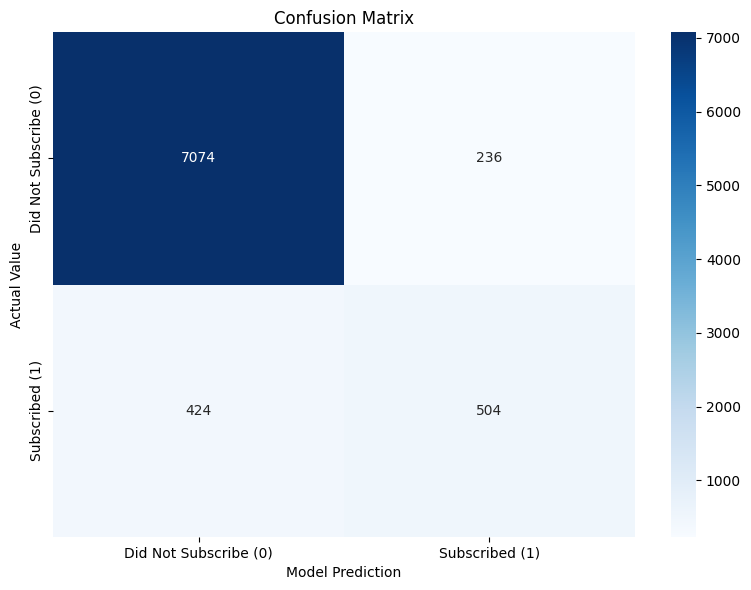

In [9]:
#Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Did Not Subscribe (0)', 'Subscribed (1)'],
            yticklabels=["Did Not Subscribe (0)", "Subscribed (1)"])
plt.xlabel('Model Prediction')
plt.ylabel('Actual Value')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()


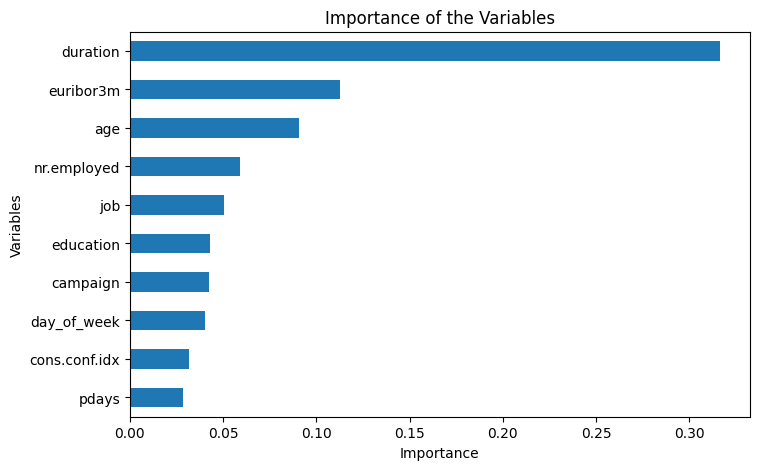

In [10]:
#Vertical Bar Chart Importance
import pandas as pd
import matplotlib.pyplot as plt

# Determine the importance of the variables
Importance = pd.Series(rf_model.feature_importances_, index=X_train.columns).nlargest(10)

plt.figure(figsize=(8,5))
Importance.plot(kind='barh')
plt.title('Importance of the Variables')
plt.xlabel('Importance')
plt.ylabel('Variables')
plt.gca().invert_yaxis()
plt.show()

In [11]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


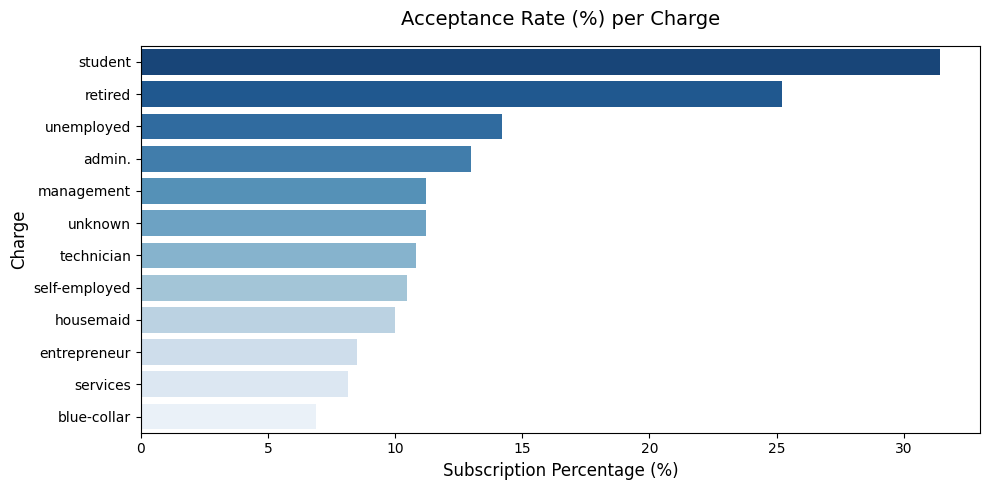

In [12]:
#Vertical Bar Chart Job
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

conversion_job = df.groupby('job')['y'].apply(lambda x: (x=='yes').mean()*100).reset_index()
conversion_job = conversion_job.sort_values(by='y', ascending=False)


plt.figure(figsize=(10, 5))
sns.barplot(data=conversion_job, x='y', y='job', hue='job', palette='Blues_r')

plt.title('Acceptance Rate (%) per Charge', fontsize=14, pad=15)
plt.xlabel('Subscription Percentage (%)', fontsize=12)
plt.ylabel('Charge', fontsize=12)

plt.tight_layout()
plt.show()

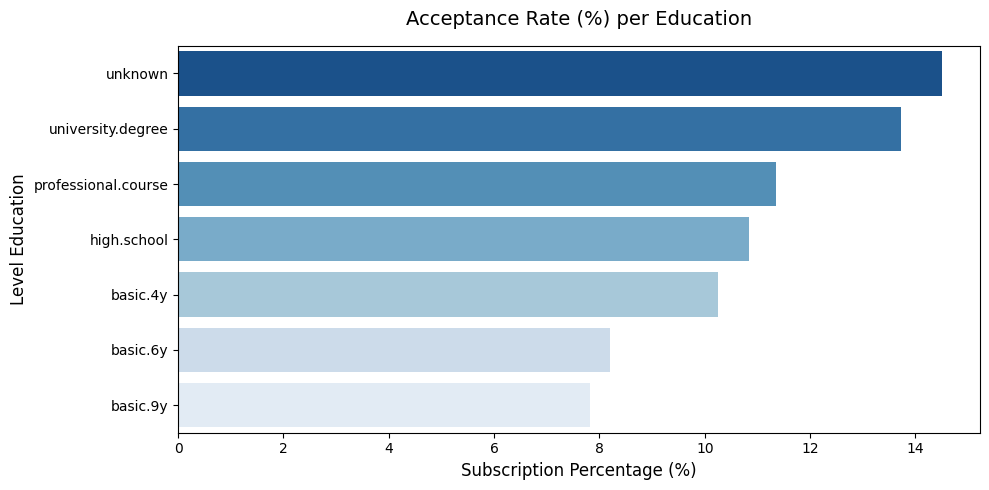

In [13]:
#Vertical Bar Chart Education
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

conversion_education = df.groupby('education')['y'].apply(lambda x: (x=='yes').mean()*100)

total = df['education'].value_counts()

edu_stats = pd.DataFrame({
    'total_clientes': total,
    'porcentaje': conversion_education
}).reset_index()

edu_stats_filtrado = edu_stats[edu_stats['total_clientes'] >= 50].sort_values(by='porcentaje', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=edu_stats_filtrado, x='porcentaje', y='education', hue='education', palette='Blues_r')

plt.title('Acceptance Rate (%) per Education', fontsize=14, pad=15)
plt.xlabel('Subscription Percentage (%)', fontsize=12)
plt.ylabel('Level Education', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
# See the full distribution of education
print(df['education'].value_counts())

education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64


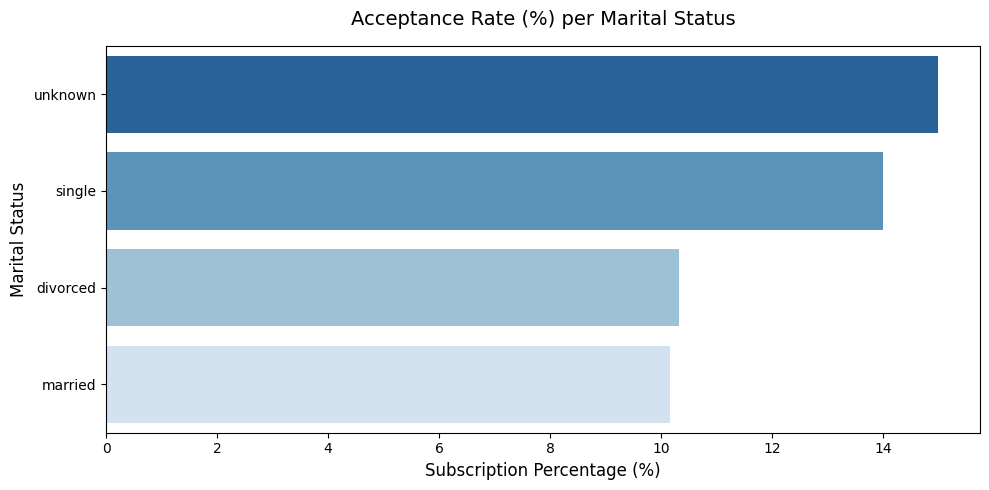

In [14]:
#Vertical Bar Chart Marital
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

conversion_marital = df.groupby('marital')['y'].apply(lambda x: (x=='yes').mean()*100).reset_index()
convesion_marital = conversion_marital.sort_values(by='y', ascending=False)

plt.figure(figsize=(10,5))

sns.barplot(data=convesion_marital, x='y', y='marital', hue='marital', palette='Blues_r')

plt.title('Acceptance Rate (%) per Marital Status', fontsize=14, pad=15)
plt.xlabel('Subscription Percentage (%)', fontsize=12)
plt.ylabel('Marital Status', fontsize=12)

plt.tight_layout()
plt.show()

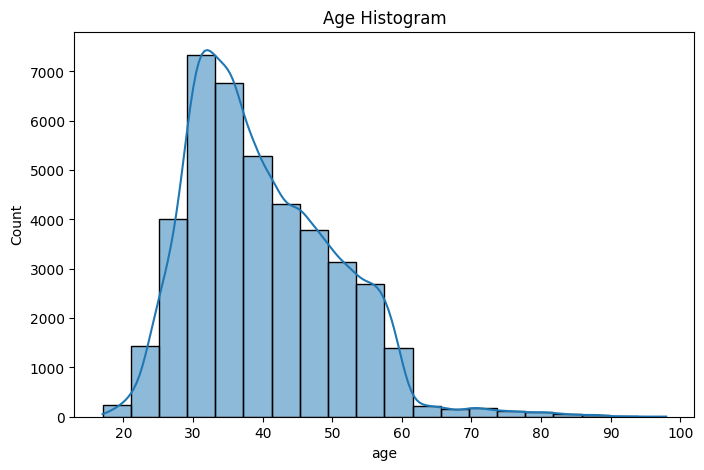

In [15]:
#Histogram Age
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(df["age"], bins=20, kde=True)
plt.title("Age Histogram")
plt.show()

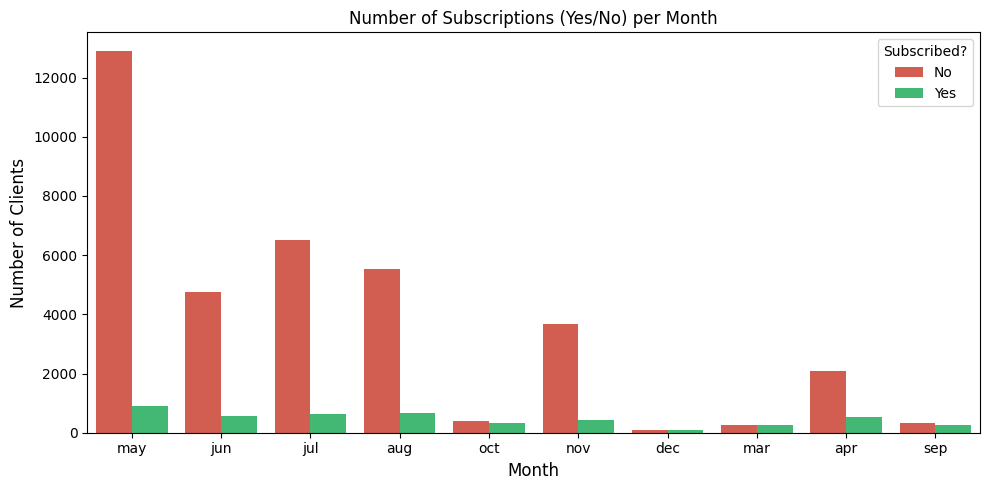

In [16]:
#Grouped Vertical Bar Chart Months
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.countplot(data=df, x='month', hue='y', palette={'yes': '#2ecc71', 'no': '#e74c3c'})
plt.title("Number of Subscriptions (Yes/No) per Month")
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Clients', fontsize=12)
plt.legend(title='Subscribed?', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

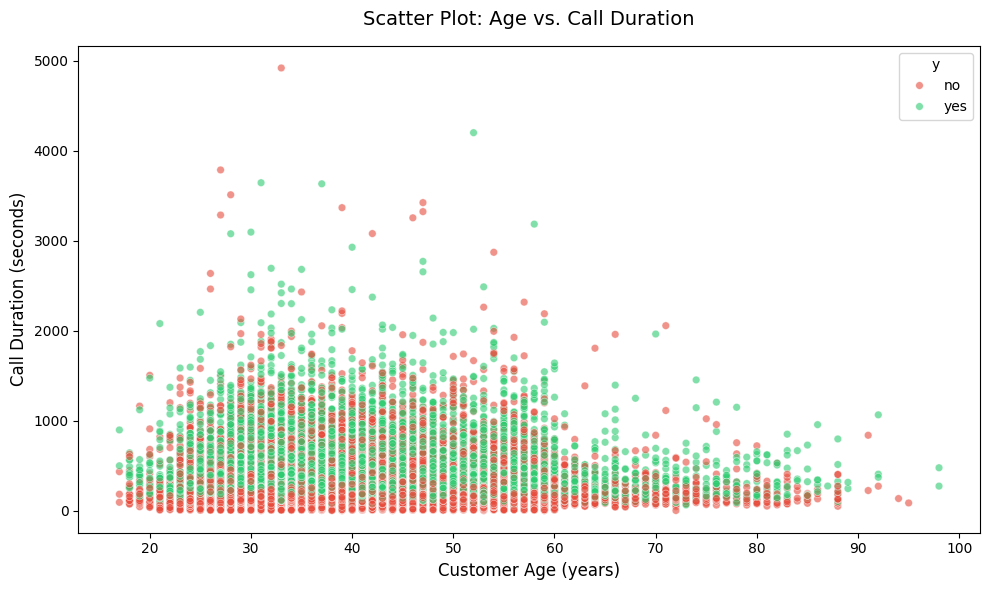

In [19]:
#Scatterplot Ege Duration
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))


sns.scatterplot(
    data=df,
    x='age',
    y='duration',
    hue='y',
    palette={'yes': '#2ecc71', 'no': '#e74c3c'},
    alpha=0.6,
    s=30
)

plt.title('Scatter Plot: Age vs. Call Duration', fontsize=14, pad=15)
plt.xlabel('Customer Age (years)', fontsize=12)
plt.ylabel('Call Duration (seconds)', fontsize=12)


plt.tight_layout()
plt.show()

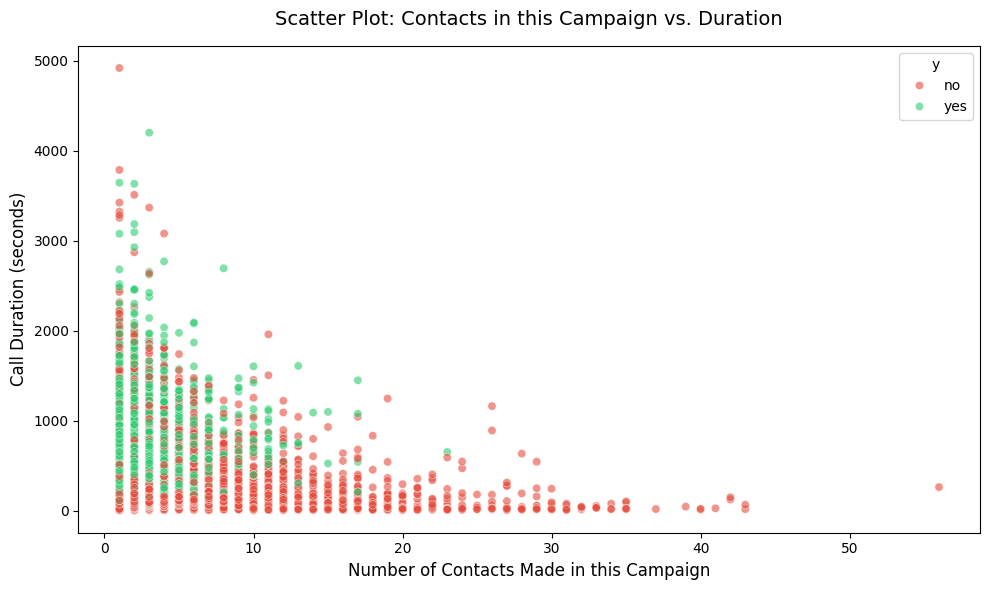

In [18]:
#Scatterplot
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='campaign',
    y='duration',
    hue='y',
    palette={'yes': '#2ecc71', 'no': '#e74c3c'},
    alpha=0.6
)

plt.title('Scatter Plot: Contacts in this Campaign vs. Duration', fontsize=14, pad=15)
plt.xlabel('Number of Contacts Made in this Campaign', fontsize=12)
plt.ylabel('Call Duration (seconds)', fontsize=12)

plt.tight_layout()
plt.show()

In [21]:
#Customers who will say yes to contact
import pandas as pd

probabilibades_si = rf_model.predict_proba(X_test)[:, 1]

df_results = df.loc[X_test.index].copy()
df_results['Probability_Success_%'] = (probabilibades_si*100).round(2)
df_results['Model_Prediction']=rf_model.predict(X_test)

#Collect information from the clients with the highest percentage
top_calls = df_results.sort_values(
    by='Probability_Success_%',
    ascending=False
).head(10)

#Display the collected information
interest_columns = ['age', 'job', 'marital', 'education', 'contact', 'duration', 'Probability_Success_%']
print("--- TOP 10 PRIORITY CUSTOMERS TO CALL ---")
top_calls[interest_columns]

--- TOP 10 PRIORITY CUSTOMERS TO CALL ---


,age,job,marital,education,contact,duration,Probability_Success_%
40476,42,technician,married,professional.course,cellular,295,100.0
40473,66,admin.,divorced,university.degree,cellular,222,97.0
40487,33,admin.,married,university.degree,cellular,265,97.0
40359,58,blue-collar,married,basic.4y,cellular,771,96.0
39153,21,student,single,basic.9y,cellular,363,96.0
39644,48,unemployed,married,professional.course,cellular,236,96.0
39676,76,retired,married,basic.4y,cellular,1205,96.0
40567,37,admin.,married,university.degree,cellular,265,96.0
39221,34,admin.,single,university.degree,cellular,241,95.0
39614,78,retired,divorced,basic.4y,cellular,218,95.0


In [22]:
customer_top1 = top_calls.iloc[0]

print(f"Age: {customer_top1['age']}")
print(f"Job: {customer_top1['job']}")
print(f"Call duration: {customer_top1['duration']} seconds ({round(customer_top1['duration']/60, 1)} minutes)")
print(f"Previous campaign result (poutcome): {customer_top1['poutcome']}")
print(f"3m Euribor rate: {customer_top1['euribor3m']}")

Age: 42
Job: technician
Call duration: 295 seconds (4.9 minutes)
Previous campaign result (poutcome): success
3m Euribor rate: 0.899


In [23]:
#Save the Model
import joblib

joblib.dump(scaler, 'scaler_bank_marketing.joblib')
joblib.dump(rf_model, 'rf_model.joblib')
print("Model saved successfully.")

Model saved successfully.
